In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from factor_diffusion_train import FactorDenoiser
from factor_diffusion_levy import levy_noise_schedule
from factor_diffusion_sample import generate, generate_rejection
import matplotlib.patches as mpatches
import yaml
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from test_generate import plot_var_grad

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


-  max is increasing via sample size and it is not stable in market factor
- N = 4096 other fatcor are stable

In [2]:
# train / sampling config
with open("cfg.yaml") as f:
    _all_cfg = yaml.safe_load(f)
    _tcfg    = _all_cfg["train"]
    _scfg    = _all_cfg["sample"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_TIMESTEPS = _tcfg["num_timesteps"]
LEVY_ALPHA    = _tcfg["levy_alpha"]
PREFIX        = _tcfg["prefix"]
BATCH_SIZE    = _tcfg["batch_size"]
FACTOR_NAMES  = _tcfg["factor_names"]
NUM_GENERATE  = _scfg["num_generate"]
FACTOR_DIM    = len(_tcfg["factor_names"])
CHECKPOINT    = f"{PREFIX}/checkpoints/factor_DLPM_ep0200.pt"
OUT_PATH      = f"{PREFIX}/samples/factor_{NUM_GENERATE}.npy"

In [3]:
# util functions
def _to_norm(scaler, value, idx):
    dummy = np.zeros((1, FACTOR_DIM))
    dummy[0, idx] = value
    return float(scaler.transform(dummy)[0, idx])

def make_cond_fn(interval, scaler, feature_idx=0):
    thl, thr = interval
    qmin_norm = _to_norm(scaler, thl, feature_idx)
    qmax_norm = _to_norm(scaler, thr, feature_idx)

    def cond_fn(x0_hat):
        return (torch.relu(x0_hat[:, feature_idx] - qmax_norm) +
                torch.relu(qmin_norm - x0_hat[:, feature_idx]))
    cond_fn.label = f"{FACTOR_NAMES[feature_idx]} between [{thl:.4f}, {thr:.4f}]"
    return cond_fn

In [4]:
# load achievements
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
gammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)
scaler = ckpt["scaler"]
args   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)

In [5]:
"""
Ns = [128, 256, 512, 1028, 2048, 4096, 10000]
uncons = [generate(*args, num_samples=N) for N in Ns]
maxns = [np.max(uncon[0], axis=0) for uncon in uncons]
maxns
q3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]
qmins = [uncon[0].min(axis=0) for uncon in uncons]
fidx  = FACTOR_NAMES.index("momentum")
conds = []
for q3, qmin in zip(q3s, qmins):
    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)
    conds.append(cond)

cons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)
         for c, n in zip(conds, Ns)]
maxns = [np.max(con[0], axis) for con in cons]
maxns
"""

'\nNs = [128, 256, 512, 1028, 2048, 4096, 10000]\nuncons = [generate(*args, num_samples=N) for N in Ns]\nmaxns = [np.max(uncon[0], axis=0) for uncon in uncons]\nmaxns\nq3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]\nqmins = [uncon[0].min(axis=0) for uncon in uncons]\nfidx  = FACTOR_NAMES.index("momentum")\nconds = []\nfor q3, qmin in zip(q3s, qmins):\n    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)\n    conds.append(cond)\n\ncons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)\n         for c, n in zip(conds, Ns)]\nmaxns = [np.max(con[0], axis) for con in cons]\nmaxns\n'

In [6]:
# unconditional sample and conditional config
GUIDANCE_S = 5 # guidance scale
N = 4096 # sample number
uncon, _, _  = generate(*args, num_samples=N)

In [7]:
q3   = np.percentile(uncon, 3,  axis=0)
qmin = uncon.min(axis=0)
fidx = FACTOR_NAMES.index("momentum")
lower001_fn  = make_cond_fn((qmin[fidx], q3[fidx]),  scaler, fidx)
lower001, var_history, grad_history  = generate(*args, cond_fn=lower001_fn,  guidance_scale=GUIDANCE_S, num_samples=N)
print(lower001_fn.label)

momentum between [-0.0141, -0.0046]


In [8]:
import os

REJ_CACHE = f"{PREFIX}/samples/rej_momentum_bottom3pct_N{N}_s{GUIDANCE_S}.npy"

if os.path.exists(REJ_CACHE):
    rej = np.load(REJ_CACHE)
    print(f"Loaded cached rej samples from {REJ_CACHE}  shape={rej.shape}")
else:
    print("Cache not found, running rejection sampling (slow)...")
    rej = generate_rejection(*args, cond_fn=lower001_fn,
                             num_samples=N, hard=False,
                             guidance_scale=GUIDANCE_S)
    np.save(REJ_CACHE, rej)
    print(f"Saved to {REJ_CACHE}  shape={rej.shape}")

Loaded cached rej samples from model/regression/samples/rej_momentum_bottom3pct_N4096_s5.npy  shape=(4096, 7)


In [9]:
def plot_vol_panel(ax, xlim, title_suffix, datasets, fidx, threshold=None):
    for label, data, color in datasets:
        col     = data[:, fidx] if data.ndim == 2 else data
        clipped = col[(col >= xlim[0]) & (col <= xlim[1])]
        if len(clipped) < 2:
            continue
        ax.hist(clipped, bins=40, density=True, alpha=0.55,
                color=color, label=label, edgecolor="white", linewidth=0.4)
        kde = gaussian_kde(col, bw_method=0.3)
        x_grid = np.linspace(xlim[0], xlim[1], 400)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    if threshold is not None:
        ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
                   label=f"threshold = {threshold:.4f}")
    ax.set_xlabel(FACTOR_NAMES[fidx])
    ax.set_ylabel("density")
    ax.set_xlim(xlim)
    ax.set_title(title_suffix)
    ax.legend(fontsize=8, framealpha=0.9)
    for i, (label, data, color) in enumerate(datasets):
        col     = data[:, fidx] if data.ndim == 2 else data
        pct     = (col <= threshold).mean() * 100 if threshold is not None else float("nan")
        visible = ((col >= xlim[0]) & (col <= xlim[1])).sum()
        ax.text(0.02, 0.97 - i * 0.10,
                f"{label}: {pct:.0f}% <= thr  ({visible}/{len(col)} visible)",
                transform=ax.transAxes, fontsize=8,
                color=color, va="top")

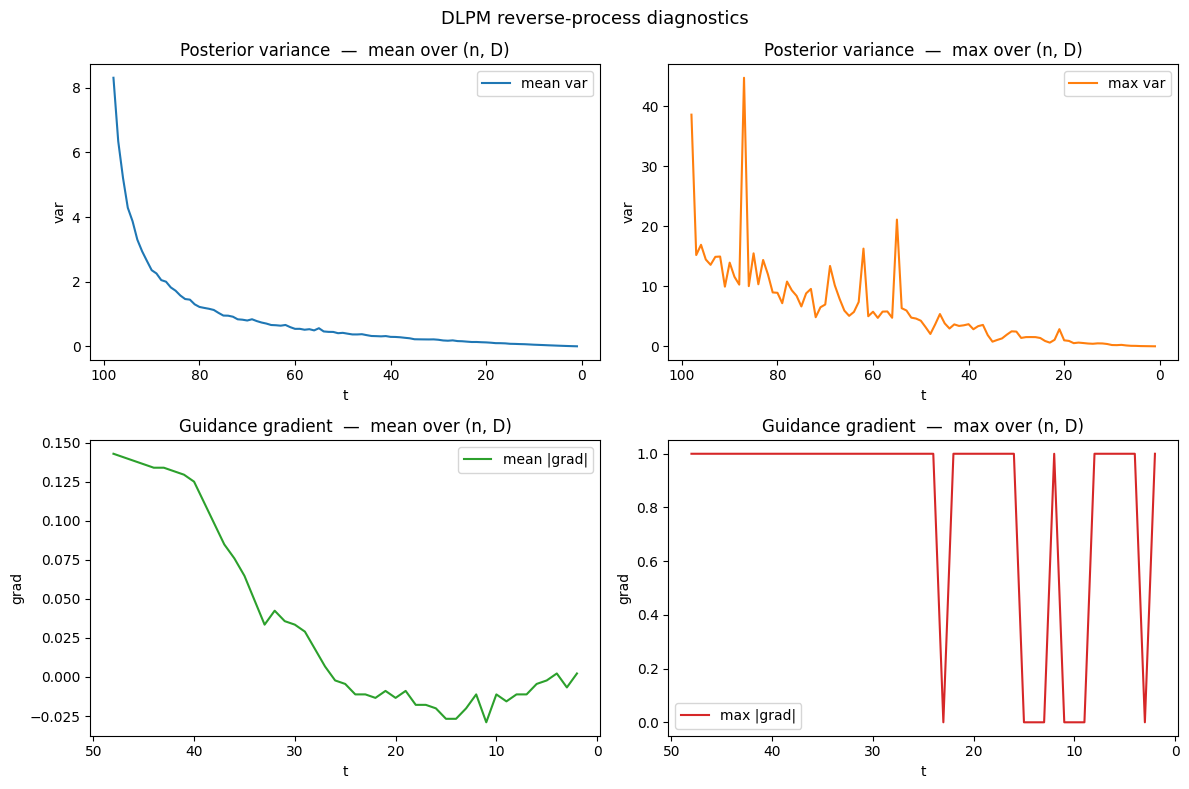

In [10]:
f = plot_var_grad(var_history, grad_history)

In [11]:
COLORS = {
    "uncon":  "#888888",
    "con":    "#2196F3",
}
datasets = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("con",   lower001, COLORS["con"]),
]

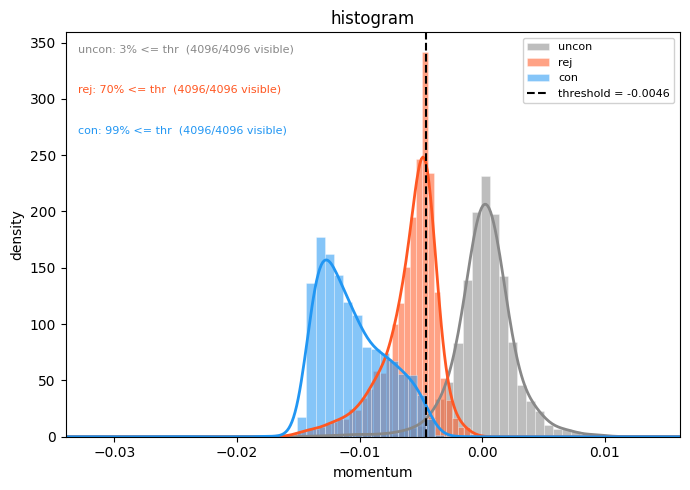

In [12]:
datasets_hist = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("rej",   rej,      "#FF5722"),
    ("con",   lower001, COLORS["con"]),
]
all_data = np.concatenate([d[:, fidx] for _, d, _ in datasets_hist])
full_lim = (all_data.min() - abs(all_data.min()) * 0.05,
            all_data.max() + abs(all_data.max()) * 0.05)
fig2, ax_full = plt.subplots(figsize=(7, 5))
plot_vol_panel(ax_full, full_lim, "histogram", datasets_hist, fidx=fidx, threshold=q3[fidx])
fig2.tight_layout()
plt.show()

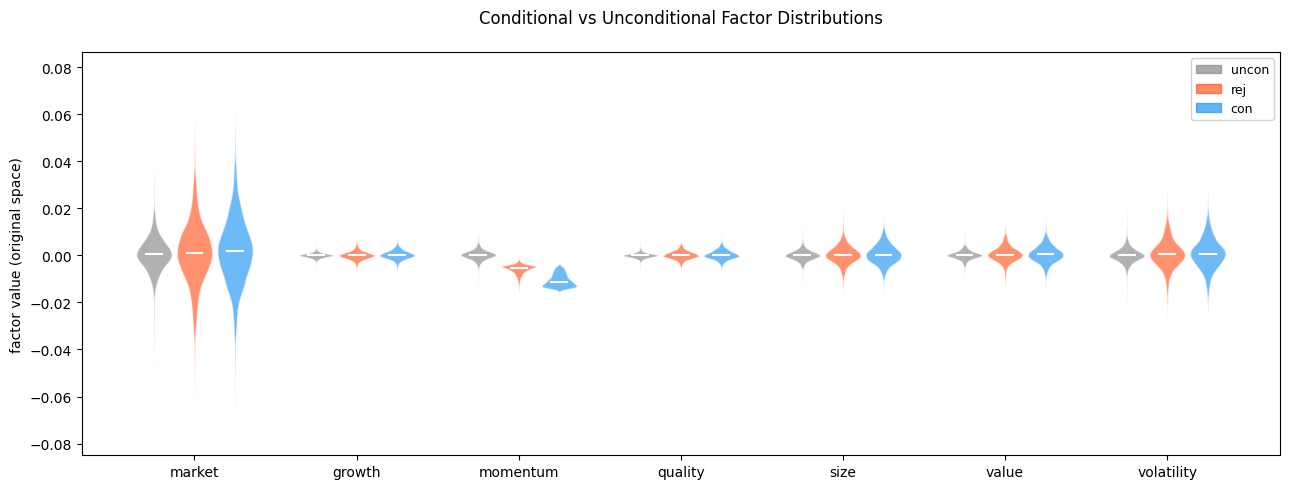

In [13]:
datasets = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("rej",   rej,      "#FF5722"),
    ("con",   lower001, COLORS["con"]),
]
x_center = np.arange(FACTOR_DIM)
offsets  = [-0.25, 0.0, 0.25]
fig, ax = plt.subplots(figsize=(13, 5))

for offset, (label, data, color) in zip(offsets, datasets):
    parts = ax.violinplot(
        [data[:, i] for i in range(FACTOR_DIM)],
        positions=x_center + offset,
        widths=0.22,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor("white")
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

ax.set_xticks(x_center)
ax.set_xticklabels(FACTOR_NAMES, fontsize=10)
ax.set_ylabel("factor value (original space)")
ax.set_title(
    f"Conditional vs Unconditional Factor Distributions\n"
)

handles = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, _, c in datasets]
ax.legend(handles=handles, fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()


### Correlation Heatmaps - Unconditional vs Conditional

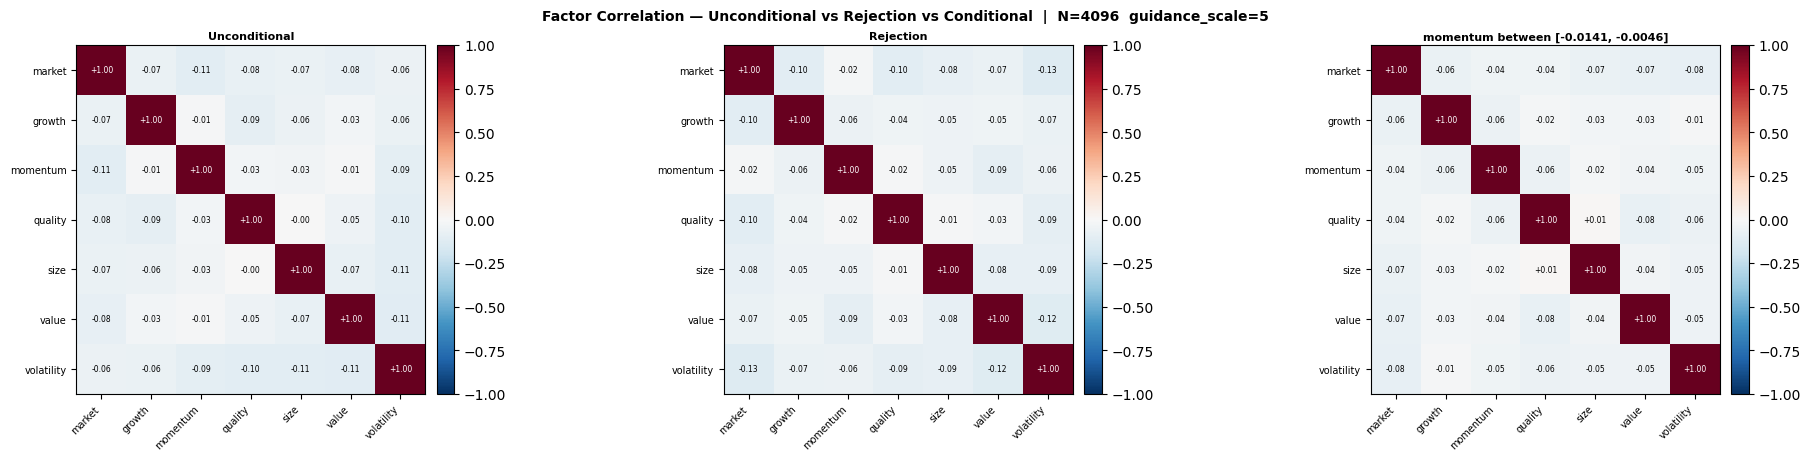

In [14]:


def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_uncon = corr_mat(uncon)
corr_rej   = corr_mat(rej)
corr_low   = corr_mat(lower001)
corr_diff  = corr_low - corr_uncon

panels = [
    ("Unconditional",   corr_uncon, TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
    ("Rejection",       corr_rej,   TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
    (lower001_fn.label, corr_low,   TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
]

fig = plt.figure(figsize=(18, 4.5), layout="constrained")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25)

for idx, (name, corr, norm, cmap) in enumerate(panels):
    ax = fig.add_subplot(gs[idx])
    im = ax.imshow(corr, cmap=cmap, norm=norm, aspect="equal")
    ax.set_xticks(range(FACTOR_DIM))
    ax.set_yticks(range(FACTOR_DIM))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=7)
    ax.set_title(name, fontweight="bold", fontsize=8, pad=4)
    for ii in range(FACTOR_DIM):
        for jj in range(FACTOR_DIM):
            ax.text(jj, ii, f"{corr[ii,jj]:+.2f}",
                    ha="center", va="center", fontsize=5.5,
                    color="white" if abs(corr[ii,jj]) > 0.4 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle(
    f"Factor Correlation — Unconditional vs Rejection vs Conditional  |  N={N}  guidance_scale={GUIDANCE_S}",
    fontsize=10, fontweight="bold"
)
plt.show()

In [15]:
mask = np.triu(np.ones((FACTOR_DIM, FACTOR_DIM), dtype=bool), k=1)
diff_vals  = corr_rej[mask]
corr_diff_rej  = corr_low - corr_uncon
print(f"Mean Δcorr diffusion guidance: {diff_vals.mean():+.4f}")
print(f"Mean Δcorr rejection sampling: {corr_diff_rej.mean():+.4f}")

Mean Δcorr diffusion guidance: -0.0663
Mean Δcorr rejection sampling: +0.0166
